In [1]:
import pandas as pd

df= pd.read_csv('/Users/gretawette/Documents/Thesis/03_Framing/outputs/media_framing_final_run_5_4mini_classifications.csv')

In [2]:
from pathlib import Path

root = Path("/Users/gretawette/Documents/Thesis")

topics = pd.read_csv(
    root / "02_TopicModeling/outputs/03_new_topic_assignments.csv",
    usecols=["row_id", "source", "Manual Topic Label", "Manual Cluster Label"],
)

# Normalise source names to match the framing CSV
topics["source"] = topics["source"].replace({
    "RT":             "RT_de",
    "Tichys Einblick": "Tichys_Einblick",
})

df = df.merge(
    topics,
    on=["row_id", "source"],
    how="left",
)

print(f"Rows: {len(df)}")
print(f"Manual Topic Label   — filled: {df['Manual Topic Label'].notna().sum()}  |  missing: {df['Manual Topic Label'].isna().sum()}")
print(f"Manual Cluster Label — filled: {df['Manual Cluster Label'].notna().sum()}  |  missing: {df['Manual Cluster Label'].isna().sum()}")
print()
print(df[["source", "row_id", "category", "Manual Topic Label", "Manual Cluster Label"]].head(10).to_string(index=False))


Rows: 11975
Manual Topic Label   — filled: 11583  |  missing: 392
Manual Cluster Label — filled: 11583  |  missing: 392

     source  row_id                         category            Manual Topic Label          Manual Cluster Label
Antispiegel       1                          NEUTRAL            AfD Party Politics         German Party Politics
Antispiegel       4 DISINFORMATION/FALSCHDARSTELLUNG Ukrainian Military Operations            Russia-Ukraine War
Antispiegel       5             VERSAGEN/INKOMPETENZ         Corruption Journalism Media & Information Ecosystem
Antispiegel       5                       IRRELEVANT         Corruption Journalism Media & Information Ecosystem
Antispiegel       5 DISINFORMATION/FALSCHDARSTELLUNG         Corruption Journalism Media & Information Ecosystem
Antispiegel       5          VERZERRUNG/MANIPULATION         Corruption Journalism Media & Information Ecosystem
Antispiegel       5          VERZERRUNG/MANIPULATION         Corruption Journalism Media

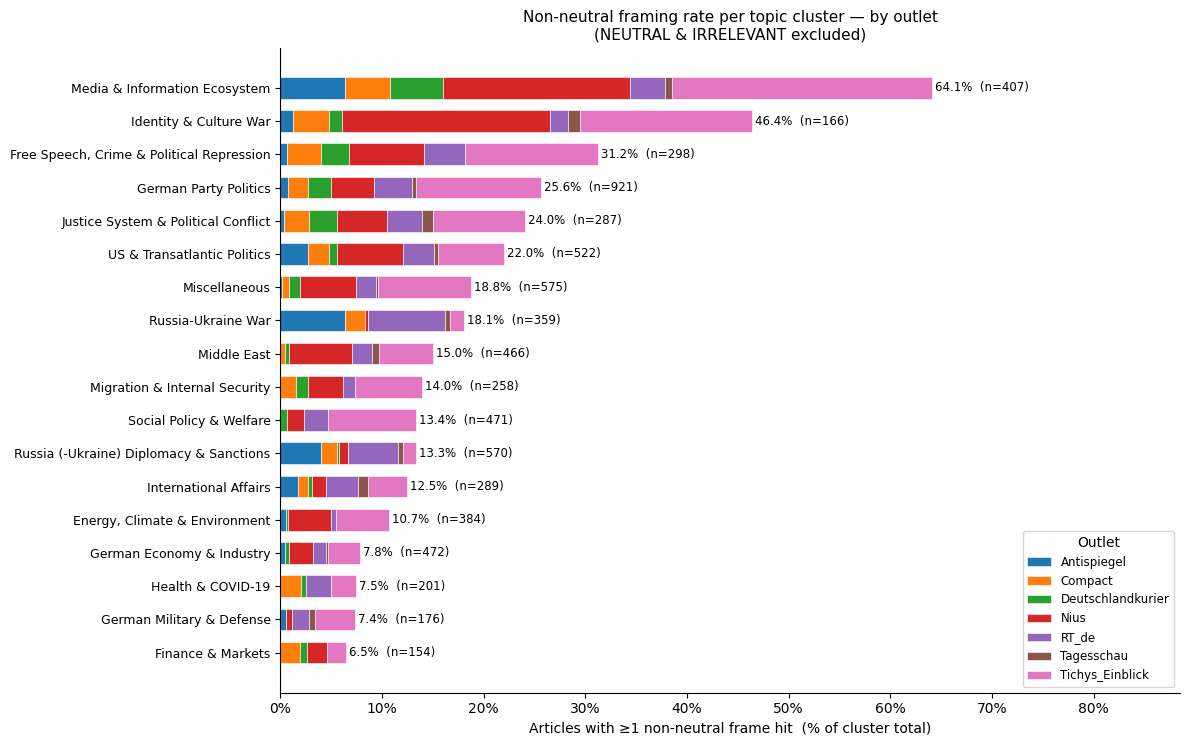

In [3]:
import matplotlib.pyplot as plt
import numpy as np

SKIP_CATS = {"NEUTRAL", "IRRELEVANT"}

# Per (cluster, outlet, article): has ≥1 non-neutral hit?
article_flags = (
    df.dropna(subset=["Manual Cluster Label"])
    .groupby(["row_id", "source", "Manual Cluster Label"])["category"]
    .apply(lambda cats: any(c not in SKIP_CATS for c in cats))
    .reset_index(name="has_frame")
)

# Total articles per cluster (denominator stays the same as before)
total_per_cluster = (
    article_flags.groupby("Manual Cluster Label")["has_frame"].count()
)

# Non-neutral articles per (cluster, outlet)
framed_per_outlet = (
    article_flags[article_flags["has_frame"]]
    .groupby(["Manual Cluster Label", "source"])
    .size()
    .unstack(fill_value=0)
)

# Convert to % of total articles in that cluster
pct_by_outlet = framed_per_outlet.div(total_per_cluster, axis=0) * 100

# Sort clusters by total non-neutral rate ascending (top = highest)
total_pct = pct_by_outlet.sum(axis=1).sort_values(ascending=True)
pct_by_outlet = pct_by_outlet.loc[total_pct.index]

outlets  = pct_by_outlet.columns.tolist()
palette  = plt.get_cmap("tab10")
OUTLET_COLORS = {o: palette(i % 10) for i, o in enumerate(sorted(outlets))}

fig, ax = plt.subplots(figsize=(12, max(6, len(pct_by_outlet) * 0.42)))

lefts = np.zeros(len(pct_by_outlet))
for outlet in sorted(outlets):
    if outlet not in pct_by_outlet.columns:
        continue
    vals = pct_by_outlet[outlet].values
    ax.barh(pct_by_outlet.index, vals, left=lefts,
            color=OUTLET_COLORS[outlet], label=outlet,
            edgecolor="white", linewidth=0.4, height=0.65)
    lefts += vals

# Total % label at bar end
for i, (cluster, total) in enumerate(total_pct.items()):
    n = int(total_per_cluster[cluster])
    ax.text(total + 0.3, i,
            f"{total:.1f}%  (n={n})",
            va="center", ha="left", fontsize=8.5)

ax.set_xlim(0, total_pct.max() * 1.38)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Articles with ≥1 non-neutral frame hit  (% of cluster total)")
ax.set_title(
    "Non-neutral framing rate per topic cluster — by outlet\n"
    "(NEUTRAL & IRRELEVANT excluded)",
    fontsize=11
)
ax.legend(loc="lower right", fontsize=8.5, frameon=True, title="Outlet")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()
